### Seasonal ARIMA (SARIMA)

In [1]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# User defined library
from stockFunctions import rmsemape
from stockFunctions import graph
from stockFunctions import conversion_single

In [3]:
# from nsepy import get_history as gh

In [4]:
# start = dt.datetime(2021,7,1)
# end = dt.datetime(2022,1,28)
# stk_data = gh(symbol='TATACOFFEE',start=start,end=end)

In [5]:
whole_data = pd.read_csv("dataset\Tatacoffee13_21.csv")

In [6]:
whole_data

,Date,Open,High,Low,Close
0,2013-01-01,1410.60,1427.90,1408.30,1415.10
1,2013-01-02,1421.00,1626.60,1416.15,1607.40
2,2013-01-03,1632.55,1673.90,1613.05,1626.20
3,2013-01-04,1627.75,1627.75,1574.60,1579.05
4,2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...,...
2220,2021-12-22,202.90,207.80,201.35,205.00
2221,2021-12-23,206.00,206.85,202.05,202.95
2222,2021-12-24,203.90,203.90,199.35,201.00
2223,2021-12-27,200.00,222.00,196.00,218.35


In [7]:
stk_data = whole_data[
    (whole_data["Date"] >= "2021-07-01") & (whole_data["Date"] <= "2022-01-28")
]

print(stk_data)

            Date    Open    High     Low   Close
2102  2021-07-01  188.60  189.00  183.00  184.55
2103  2021-07-02  183.05  187.50  182.15  186.40
2104  2021-07-05  187.85  198.35  187.85  192.45
2105  2021-07-06  193.80  194.80  187.35  188.80
2106  2021-07-07  187.80  193.95  185.40  192.85
...          ...     ...     ...     ...     ...
2220  2021-12-22  202.90  207.80  201.35  205.00
2221  2021-12-23  206.00  206.85  202.05  202.95
2222  2021-12-24  203.90  203.90  199.35  201.00
2223  2021-12-27  200.00  222.00  196.00  218.35
2224  2021-12-28  219.65  220.45  211.55  212.35

[123 rows x 5 columns]


In [8]:
stk_data = stk_data[["Open", "High", "Low", "Close"]]

In [9]:
stk_data

,Open,High,Low,Close
2102,188.60,189.00,183.00,184.55
2103,183.05,187.50,182.15,186.40
2104,187.85,198.35,187.85,192.45
2105,193.80,194.80,187.35,188.80
2106,187.80,193.95,185.40,192.85
...,...,...,...,...
2220,202.90,207.80,201.35,205.00
2221,206.00,206.85,202.05,202.95
2222,203.90,203.90,199.35,201.00
2223,200.00,222.00,196.00,218.35


In [10]:
column = "Close"

In [11]:
scaler = MinMaxScaler()
data1 = scaler.fit_transform(stk_data[[column]])

print("Len:", data1.shape)

Len: (123, 1)


In [12]:
len(data1)

123

In [13]:
import sklearn
print(sklearn.__version__)

1.9.0


In [14]:
training_size = round(len(data1 ) * 0.80)
print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]

print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]

print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

98
X_train length: (98, 1)
X_test length: (25, 1)
y_train length: (98, 1)
y_test length: (25, 1)


In [15]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
orders=[(1,1,2),(1,1,2),(2,3,1),(2,3,2)]

for order in orders:
    # print(td)
    # trendslist.append(td)
    model = SARIMAX(data1, order=order, seasonal_order=(0, 0, 0, 12))
    model_fit = model.fit()
    
    # make prediction
    # start = len(X_train)
    # end = len(X_train) + len(y_test) - 1

    y_pred = model_fit.predict(0, len(data1)-1)
    # y_pred= model_fit.predict(len(X_train), len(data1) - 1)
    
    #print(y_pred)
    #mse=mean_squared_error(y_test,y_pred,squared=False)
    
    # print("Order={}".format(order))
    # print(y_test, y_pred)
    rmsemape(data1, y_pred)
    print(" -------------------------------- ")

RMSE-Testset: 0.1034291867485994
maPe-Testset: 5347546304041.816
 -------------------------------- 
RMSE-Testset: 0.1034291867485994
maPe-Testset: 5347546304041.816
 -------------------------------- 
RMSE-Testset: 0.12528993262739532
maPe-Testset: 1673312267893.46
 -------------------------------- 
RMSE-Testset: 0.11365207636094192
maPe-Testset: 3617947844927.1255
 -------------------------------- 


In [17]:
len(y_pred)

123

In [18]:
# i = 1
# trend_ct = 'ct'
# model = AutoReg(X_train, lags=i, trend=trend_ct)
# model_fit = model.fit()

# # make prediction
# y_pred= model_fit.predict(len(X_train), len(data1) - 1)

# # print(y_pred)
# # TypeError: got an unexpected keyword argument 'squared'
# # mse = mean_squared_error(y_test,y_pred,squared=False)
# mse = mean_squared_error(y_test, y_pred)
# print("Lag={}, Trend={}".format(i, trend_ct))
# rmsemape(y_test, y_pred)
# print("--------------------------")

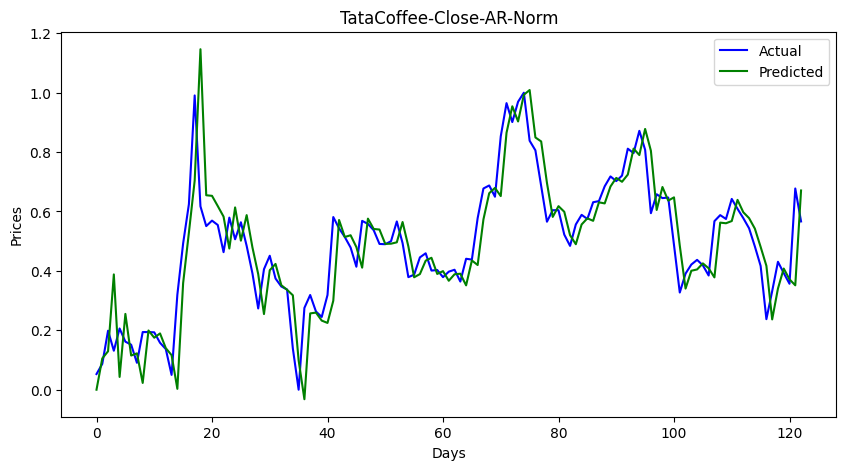

In [19]:
graph(data1, y_pred, "Actual", "Predicted", "TataCoffee-Close-AR-Norm", "Days", "Prices")

In [20]:
len(data1)

123

In [21]:
y_test

array([[0.64510166],
       [0.64695009],
       [0.487061  ],
       [0.3271719 ],
       [0.3909427 ],
       [0.42144177],
       [0.43715342],
       [0.41866913],
       [0.3844732 ],
       [0.56746765],
       [0.58780037],
       [0.57486137],
       [0.64232902],
       [0.6090573 ],
       [0.57763401],
       [0.54343808],
       [0.48243993],
       [0.4168207 ],
       [0.23752311],
       [0.33179298],
       [0.43068392],
       [0.39279113],
       [0.35674677],
       [0.67744917],
       [0.56654344]])

In [22]:
aTestNormTable = conversion_single(y_test, [column])

In [23]:
aTestNormTable

,Close
0,0.645102
1,0.64695
2,0.487061
3,0.327172
4,0.390943
5,0.421442
6,0.437153
7,0.418669
8,0.384473
9,0.567468


In [24]:
actual_stock_price_test_ori = scaler.inverse_transform(aTestNormTable)

In [25]:
actual_stock_price_test_ori

array([[216.6 ],
       [216.7 ],
       [208.05],
       [199.4 ],
       [202.85],
       [204.5 ],
       [205.35],
       [204.35],
       [202.5 ],
       [212.4 ],
       [213.5 ],
       [212.8 ],
       [216.45],
       [214.65],
       [212.95],
       [211.1 ],
       [207.8 ],
       [204.25],
       [194.55],
       [199.65],
       [205.  ],
       [202.95],
       [201.  ],
       [218.35],
       [212.35]])

In [26]:
actual_stock_price_test_oriA = conversion_single(actual_stock_price_test_ori, [column])

In [27]:
actual_stock_price_test_oriA

,Close
0,216.6
1,216.7
2,208.05
3,199.4
4,202.85
5,204.5
6,205.35
7,204.35
8,202.5
9,212.4


In [28]:
aTestNormTable = conversion_single(data1, [column])
actual_stock_price_test_ori = scaler.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA = conversion_single(actual_stock_price_test_ori, [column])

In [29]:
pTestNormTable = conversion_single(y_pred, [column])
predicted_stock_price_test_ori = scaler.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP = conversion_single(predicted_stock_price_test_ori,[column])

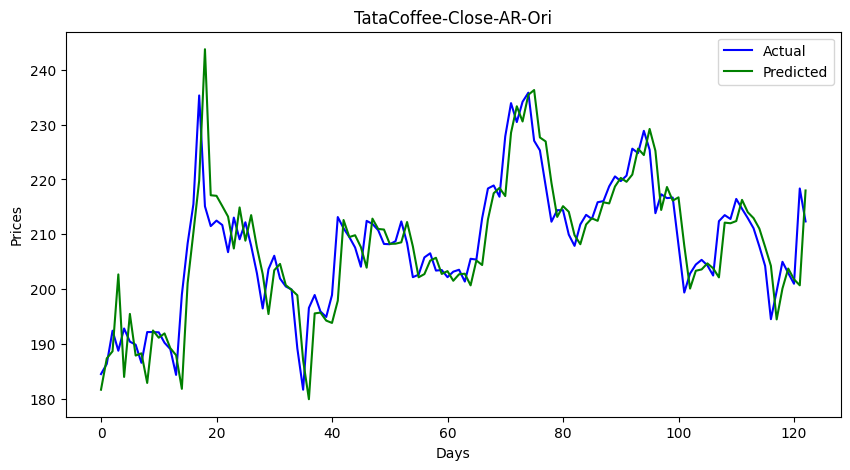

In [30]:
graph(actual_stock_price_test_oriA, predicted_stock_price_test_oriP, "Actual", "Predicted", "TataCoffee-Close-AR-Ori", "Days", "Prices")

In [31]:
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 6.148577331126963
maPe-Testset: 0.020312440804615004


In [32]:
forecast = model_fit.predict(len(data1), len(data1)+3)

In [33]:
forecast

array([0.52373102, 0.53130156, 0.52958239, 0.52190756])

In [34]:
fTestNormTable = conversion_single(forecast,["Closefore"])
forecast_stock_price_test_ori = scaler.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF = conversion_single(forecast_stock_price_test_ori, ["Closefore"])

In [35]:
forecast_stock_price_test_oriF

,Closefore
0,210.033848
1,210.443414
2,210.350407
3,209.935199
